# Phishing Email Detection Report

__Alumnos:__
- Carlos Berdaguer - a2605
- Lucas Campi - a2609

## __Introducción__

En la era moderna, el medio de comunicación más utilizado es el email, producto de ser un medio efectivo, rápido y barato. Según Kolmar (2019), 333.2 billones de mails son enviados a diario, lo que significa que el uso de mails es alto y, en adición, es bastante probable recibir un correo spam, fraude o phishing *Machine Learning Algorithms for Phishing Email Detection de Yoga Shri Murti y Palanichamy Naveen*

En el estudio *Building an Intelligent Phishing Email Detection System Using Machine 
Learning and Feature Engineering*, realizado por ingenieros de Microsoft, Code Ace, JP Morgan, Deloitte y North Start Group, sostienen lo dicho por Murti y Naveen y agregan que se evidencia que hoy en día es el tipo de cyber-ataque más común y exitoso, empleando distintas técnicas para engañar a sus objetivos. Sostienen que la importancia de la detección de phishing ha adquirido una considerable atención, y que existen múltiples técnicas y herramientas para la detección de correos phishing.

*Sristhi Rawal, Bhuvan Rawala, Aakhila Shaheen y Shubham Malik* definen el phishing como un tipo lucrativo de fraude, donde los criminales engañan a los objetivos para obtener información confidencial a partir de falsas pretensiones. Los correos phishing tienden a convencer a los receptores de clickear links o descargar archivos adjuntos con el objetivo de obtener información confidencial como contraseñas, información de tarjetas de crédito, etc. Sostienen que son enviados miles de correos a diario, que solo un pequeño porcentaje cae en la trampa pero que los daños son grandes. Citan el caso real de Google en 2017, donde se realizó un ataque masivo a alrededor de 1 billon de usuarios de Gmail, donde los usuarios recibían un correo que los redirigía a "Google Docs" y estos tenían que darle permisos a una página falsa.

En conclusión, el phishing es un tipo de ataque de ingeniería social donde un emisor envía un correo con algún tipo de contenido que busca convencer al receptor de que ese correo es real y legítimo. Muchas veces, con links o documentos adjuntos combinados con un correo lo suficientemente convincente como para que el receptor sea engañado con alguna falsa pretención.

## __Motivación__

Durante nuestros primeros cursos, se ha nombrado a los casos de *detección de SPAM* o *detección de Emails* como un tipos de problemas clásicos en el mundo de Machine Learning. Decidimos adentrarnos un poco en esta temática y, luego de leer distintos papers, descubrimos que a día de hoy sigue siendo una problemática vigente y que si bien se han desarrollado múltiples algoritmos, técnicas y herramientas para la detección de estos correos maliciosos, también evoluciona el nivel de sofisticación de este tipo de correos.
Existen múltiples algoritmos de Machine Learning para tratar esta casuística; como Naive-Baye, Nearest Neighbour, Multi-Layer perceptron, Support Vector Machine, etc.

Todo esto nos interesó a indagar más sobre este tema y creemos que es una buena oportunidad para ver un caso de Machine Learning aplicado a una problemática de la vida real.


__Bibliografía:__
*Building an Intelligent Phishing Email Detection System Using Machine 
Learning and Feature Engineering (Rao Chinta, Moore, Karaka, Sakuru, Bodepudi, Maka)*

*Phishing Detection in E-mails using Machine Learning (Rawal & Rawal, Shaheen, Malik)*
*Machine Learning Algorithms for Phishing Email Detection (Murti, Naveen)*

*Phishing Email Detection Using Inputs From Artificial Intelligence (Milthun, Bartlett, Mirkovic, Freedman)*

https://www.cnbc.com/2017/05/04/gmail-google-hack-phishing-attack.html

---

#### Descripción del dataset


| Variable      | Descripción                                                                      |
| ------------- | -------------------------------------------------------------------------------- |
| `Email Text`  | Contenido del mail                                                               |
| `Email Type`  | Es seguro o phishing                                                             |


---

In [107]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [108]:
#Importamos el dataset
email_df = pd.read_csv('./datasets/Phishing_Email.csv')

Procederemos a hacer un breve análisis sobre el dataset:

In [109]:
email_df.nunique()

Unnamed: 0    18650
Email Text    17537
Email Type        2
dtype: int64

Podemos observar que solo hay dos tipos de mail: legítimo o phishing. Luego, la variable Email Text no está completa, es decir, se tomaron observaciones que se sabe que son phishing o no pero sin registrar el correo. Para nuestro análisis particular, no tiene sentido contener estos vacíos así que vamos a eliminarlos, además, vamos a mapear la variable Email Type como una variable categórica nominal binaria para facilitar la interpretabilidad (1 = Es phishing, 0 = no lo es).

No hacemos imputación para los vacíos ya que estaríamos introduciendo información sin tener certeza nosotros de QUÉ ES y QUÉ NO ES phishing.

In [110]:
email_df = email_df.dropna()
email_df["label"] = email_df["Email Type"].apply(lambda x: 1 if x == "Phishing Email" else 0)
email_df.drop(columns=['Unnamed: 0', 'Email Type'], inplace=True)
column_duplicates = email_df['Email Text'].duplicated().sum()
column_duplicates

np.int64(1097)

Se observa que del total de mails, 1112 observaciones es el mismo correo. ¿Los duplicados estarán etiquetados todos iguales?

In [111]:
duplicate_rows = email_df[email_df['Email Text'].duplicated()]
duplicate_rows.head()

,Email Text,label
106,empty,0
130,empty,1
244,empty,1
305,empty,1
335,empty,1


Detectamos que el dataset contiene observaciones donde el campo "Email Text" contiene "empty" como texto haciendo alusión de que el mail estaba vacío. Vamos a remover los duplicados y los "empty".

In [112]:
email_df = email_df.drop_duplicates(subset=['Email Text'], keep='first')
email_df = email_df[email_df['Email Text'] != 'empty'] 

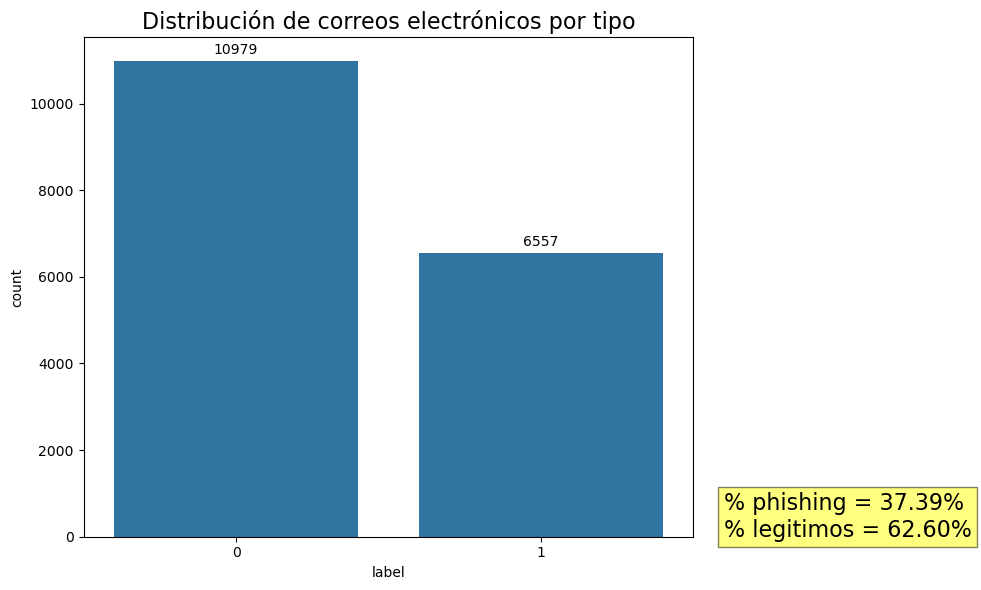

In [113]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='label', data=email_df)
ax.set_title('Distribución de correos electrónicos por tipo', fontsize=16)
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.text(1.6, 1, '% phishing = ' + str(email_df['label'].mean() * 100)[:5] + '% \n% legitimos = ' + str((1 - email_df['label'].mean()) * 100)[:5] + '%', fontsize=16, 
         bbox=dict(facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.show()

Observamos que del dataset inicial, solo el 39% fue reportado como phishing.

---

Para darle más profundidad al análisis, agregaremos tres columnas en nuestro dataset; has_link, words_count

In [114]:
email_df["word_count"] = email_df["Email Text"].apply(lambda x: len(x.split()))
email_df["has_link"] = email_df["Email Text"].apply(lambda x: 1 if "http" in x else 0)

Ahora observemos cuál es la proporción de mails que es phishing según si tiene o no link.

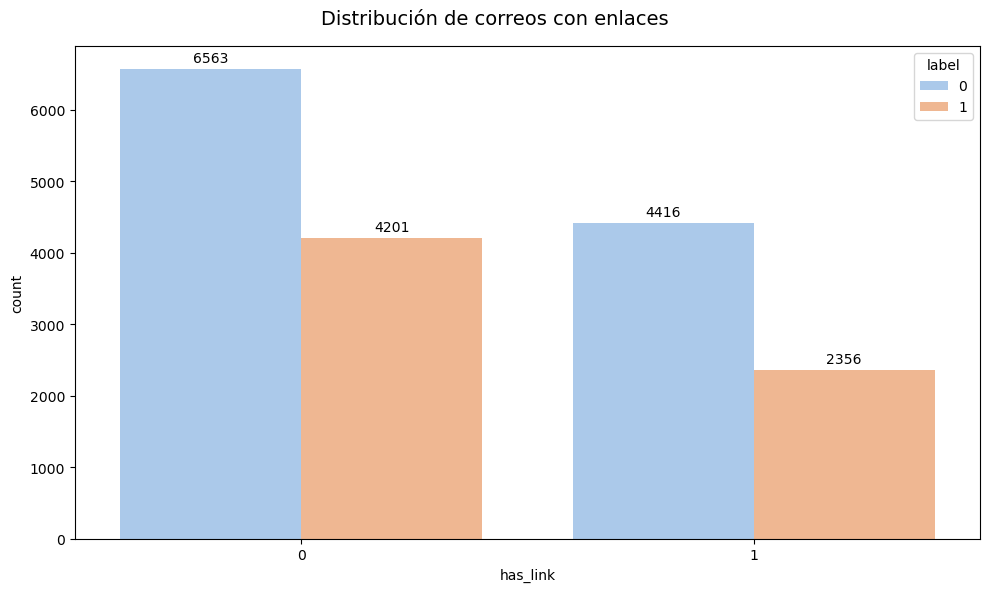

In [115]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(x='has_link', data=email_df, hue="label", palette='pastel')

plt.suptitle('Distribución de correos con enlaces', fontsize=14)
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)
    
plt.tight_layout()
plt.show()

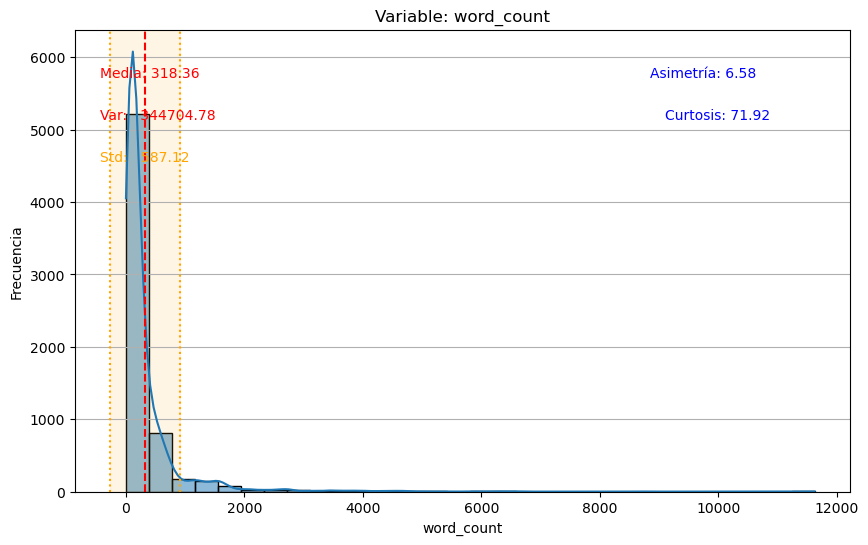

In [116]:
def plot_histograma(data, column, figsize=(6, 3), bins=15, kde=True, mvd=True, shade=True, snk=False):
    skewness = (data[column]).skew()
    kurtosis = (data[column]).kurt()
    media = (data[column]).mean()
    var = (data[column]).var()
    std = (data[column]).std()
    plt.figure(figsize=figsize)
    plt.grid(axis='y')
    sns.histplot(data[column], bins=bins, kde=kde)
    if snk:
        plt.figtext(0.7, 0.8, f'Asimetría: {skewness:.2f}', fontsize=10, color='blue')
        plt.figtext(0.715, 0.73, f'Curtosis: {kurtosis:.2f}', fontsize=10, color='blue')
        plt.axvline(media, color='red', linestyle='--', label='Media')
 

    if mvd and shade:
        plt.axvspan(media - std, media + std, alpha=0.1, color='orange', label='±1 Std')
        plt.axvline(media + std, color='orange', linestyle=':', label='+1 Std')
        plt.axvline(media - std, color='orange', linestyle=':', label='-1 Std')
        plt.figtext(0.15, 0.80, f'Media: {media:.2f}', fontsize=10, color='red')
        plt.figtext(0.15, 0.73, f'Var:   {var:.2f}',   fontsize=10, color='red')
        plt.figtext(0.15, 0.66, f'Std:   {std:.2f}',   fontsize=10, color='orange')

    

    plt.title(f'Variable: {column}')
    plt.xlabel(f'{column}')
    plt.ylabel('Frecuencia')
    plt.show()
    
    return

plot_histograma(email_df[email_df['label'] == 1], 'word_count', figsize=(10, 6), bins=30, kde=True, mvd=True, shade=True, snk=True) 

Se puede observar que hay outliers con cantidades descomunales de palabras. Vamos a filtrar utilizando el límite superior calculado a partir del rango intercuartil para poder hacer un mejor análisis de los correos.

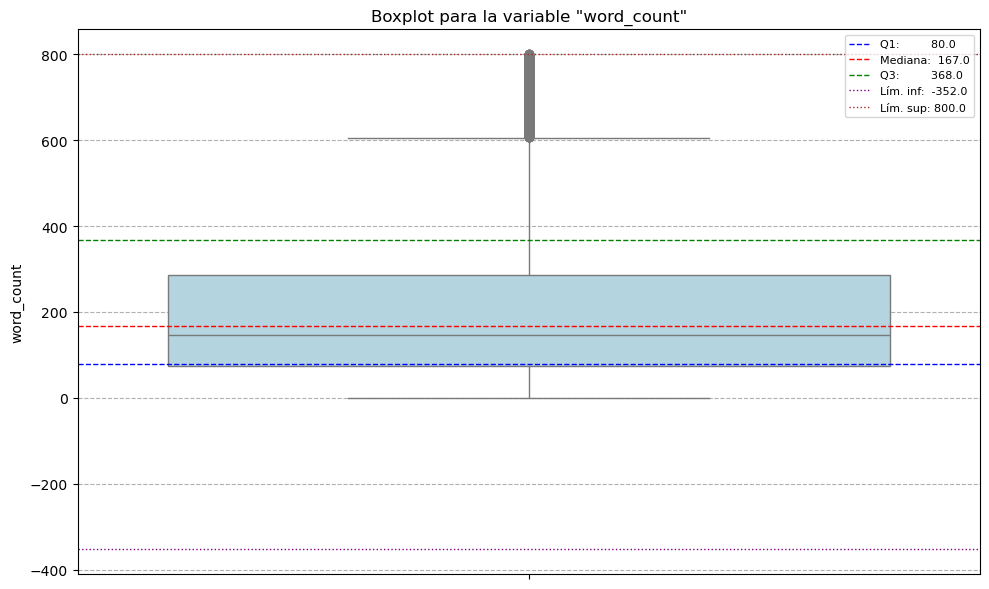

In [117]:

plt.figure(figsize=(10, 6))

word_count = email_df['word_count']

word_count_Q1 = word_count.quantile(0.25)
word_count_Q2 = word_count.quantile(0.50)
word_count_Q3 = word_count.quantile(0.75)
word_count_IQR = word_count_Q3 - word_count_Q1
lower_limit = word_count_Q1 - 1.5 * word_count_IQR
upper_limit = word_count_Q3 + 1.5 * word_count_IQR

email_df = email_df[(email_df['word_count'] <= upper_limit) & (email_df['word_count'] >= lower_limit)]

ax = sns.boxplot(data=email_df, y='word_count', color="lightblue")
ax.axhline(word_count_Q1,      color='blue',   linestyle='--', linewidth=1, label=f'Q1:         {word_count_Q1:.1f}')
ax.axhline(word_count_Q2,      color='red',    linestyle='--', linewidth=1, label=f'Mediana:  {word_count_Q2:.1f}')
ax.axhline(word_count_Q3,      color='green',  linestyle='--', linewidth=1, label=f'Q3:         {word_count_Q3:.1f}')
ax.axhline(lower_limit, color='purple', linestyle=':',  linewidth=1, label=f'Lím. inf:  {lower_limit:.1f}')
ax.axhline(upper_limit, color='brown',  linestyle=':',  linewidth=1, label=f'Lím. sup: {upper_limit:.1f}')
ax.set_title('Boxplot para la variable "word_count"')
ax.legend(fontsize=8)
ax.grid(axis='y', ls='--')

plt.tight_layout()
plt.show()


Vamos a utilizar los cuartiles calculados para categorizar la variable words_count en tres

In [118]:
email_df["words_count_cat"] = email_df["word_count"].apply(lambda x: 'bajo' if x < word_count_Q1 else ('medio' if x < word_count_Q3 else 'largo'))
email_df.value_counts('words_count_cat')

words_count_cat
medio    8806
bajo     4345
largo    2777
Name: count, dtype: int64

Ahora tenemos un mejor panorama, vamos a proceder a hacer el análisis de cantidad de palabras para aquellos correos con phishing y sin phishing

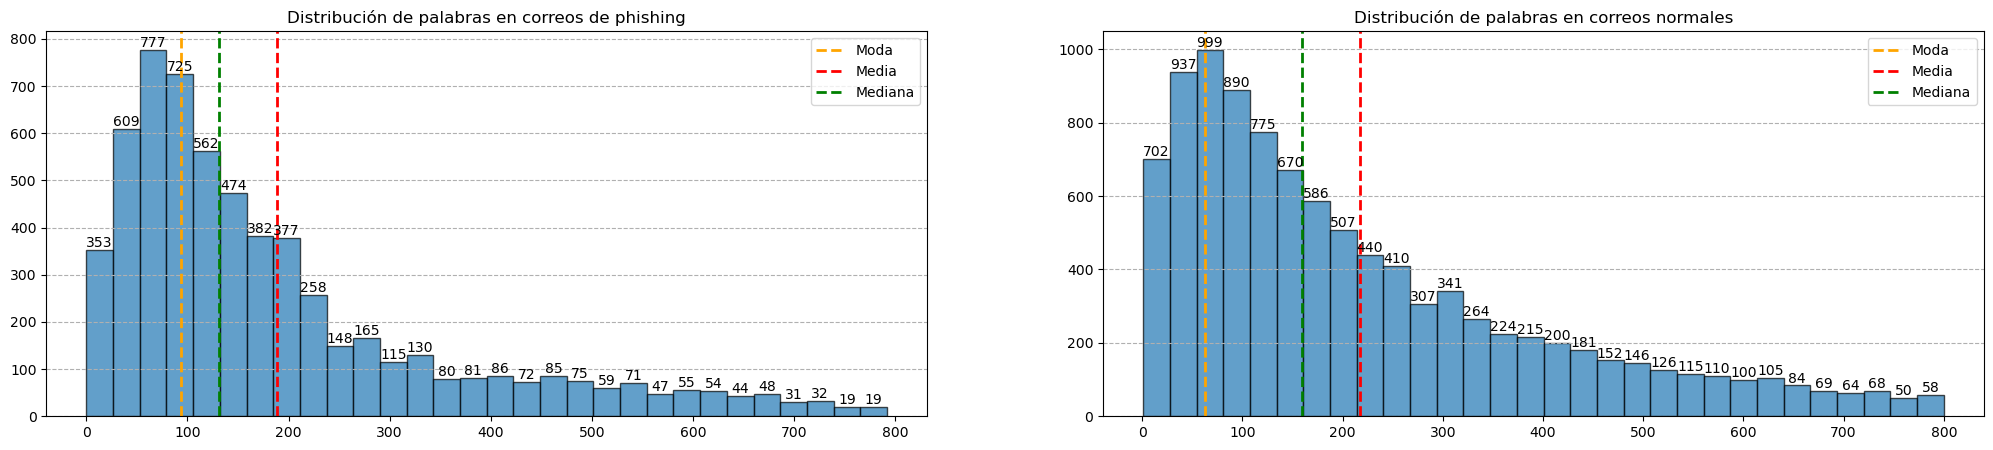

In [119]:
fig, axes = plt.subplots(1, 2, figsize=(25, 5))

def plot_distribution(ax, data, title):
    ax.hist(data, bins=30, alpha=0.7, edgecolor='black')
    ax.axvline(data.mode()[0], color='orange',  linestyle='dashed',  linewidth=2, label='Moda')
    ax.axvline(data.mean(), color='red', linestyle='dashed', linewidth=2, label='Media')
    ax.axvline(data.median(), color='green', linestyle='dashed', linewidth=2, label='Mediana')
    ax.grid(axis='y', ls='--')
    ax.set_title(title)
    ax.bar_label(ax.containers[0])
    ax.legend()

plot_distribution(axes[0], email_df[email_df['label'] == 1]['word_count'], 'Distribución de palabras en correos de phishing')
plot_distribution(axes[1], email_df[email_df['label'] == 0]['word_count'], 'Distribución de palabras en correos normales')

Se puede observar que la cantidad de palabras no es un factor influyente para determinar si un correo es o no phishing, de hecho, las distribuciones nos dicen que los correos identificados como normales tienen mayor cantidad de palabras en la mediana.

Fijemonos ahora según la categoría de la cantidad de palabras.

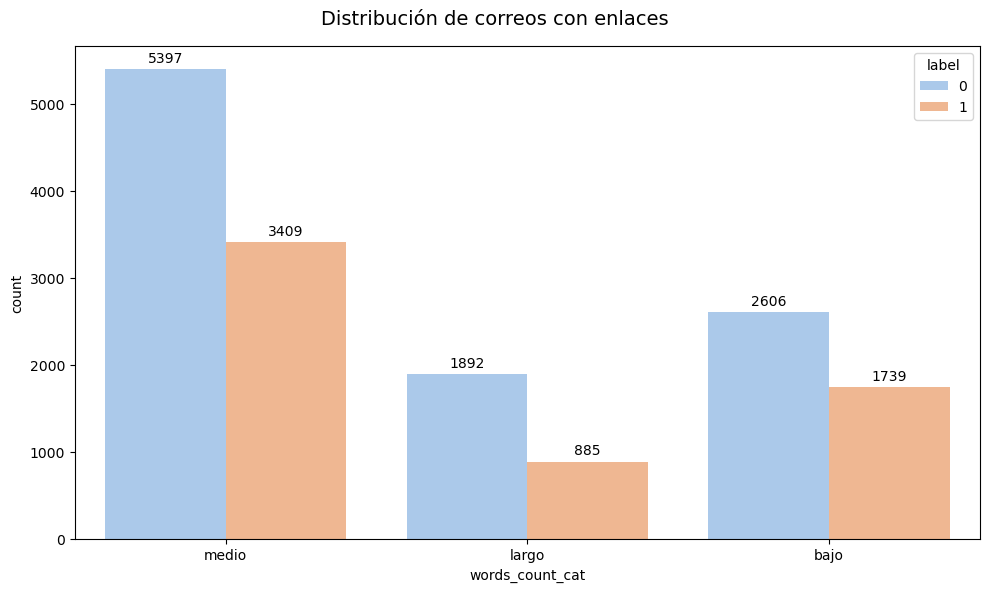

In [120]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(x='words_count_cat', data=email_df, hue="label", palette='pastel')

plt.suptitle('Distribución de correos con enlaces', fontsize=14)
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)
    
    
plt.tight_layout()
plt.show()


Podemos observar que los correos con mayor cantidad de palabras, tienden a, en proporción, ser menos propensos a phishing. Luego, para los correos medio y bajo, si bien la mayoría de casos no es phishing, más de la mitad si lo es, siendo los de categoría "medio" aquellos más propensos a ser phishing.